In [1]:
import polars as pl
import matplotlib.pyplot as plt

from spells import summon, ColSpec, ColType, ColName
from spells.columns import agg_col
from deq.plot import line_plot
from deq.pick_rate import *

In [2]:
set_code = "TDM"

means_df = prl_df("TDM")
df = by_pick_df("TDM").join(means_df, on="name")

In [28]:
cards = [
    "Death Begets Life",
]

card_df = df.filter(~pl.col('pick_rate_logit').is_null()).filter(pl.col('name').is_in(cards)).filter(pl.col('pick_num') < 10)
# card_df = df.filter(pl.col('rarity') == "common").filter(pl.col('ata') > 3).filter(pl.col('ata') < 7)
# card_means = means_df.filter(pl.col('rarity') == "common").filter(pl.col('ata') > 3).filter(pl.col('ata') < 7)
card_means = means_df.filter(pl.col('name').is_in(cards))

In [27]:
pl.Config.set_tbl_rows(1000)
means_df.sort("npr_seen", descending=True)

name,pick_odds,npr,npr_seen,alsa,pick_rate_logit,pick_rate_logit_seen,num_seen,num_taken,pack_card,rarity,ata
str,f64,f64,f64,f64,f64,f64,i64,i32,i64,str,f64
"""Ugin, Eye of the Storms""",248.026993,7.954353,7.954353,1.049608,8.067222,8.067222,383,364,383,"""mythic""",1.049451
"""Elspeth, Storm Slayer""",101.455704,6.664706,6.664706,1.095368,6.879505,6.879505,367,328,367,"""mythic""",1.106707
"""Marang River Regent""",35.353438,5.143779,5.143779,1.404737,5.992768,5.992768,971,796,971,"""rare""",1.403266
"""Ureni, the Song Unending""",33.343881,5.05935,5.05935,1.508584,6.099764,6.099764,466,387,466,"""mythic""",1.498708
"""Sage of the Skies""",31.203896,4.963654,4.963654,1.46928,5.932886,5.932886,944,768,944,"""rare""",1.470052
"""Dragonback Assault""",30.600439,4.93548,4.93548,1.472885,5.911306,5.911306,461,374,461,"""mythic""",1.508021
"""Jeskai Revelation""",20.70117,4.37164,4.38424,1.798669,5.889643,5.902243,601,487,602,"""mythic""",1.800821
"""Shiko, Paragon of the Way""",19.623532,4.294513,4.294513,1.584211,5.467546,5.467546,570,433,570,"""mythic""",1.56582
"""Warden of the Grove""",19.587122,4.291834,4.291834,1.448276,5.222392,5.222392,957,696,957,"""rare""",1.448276


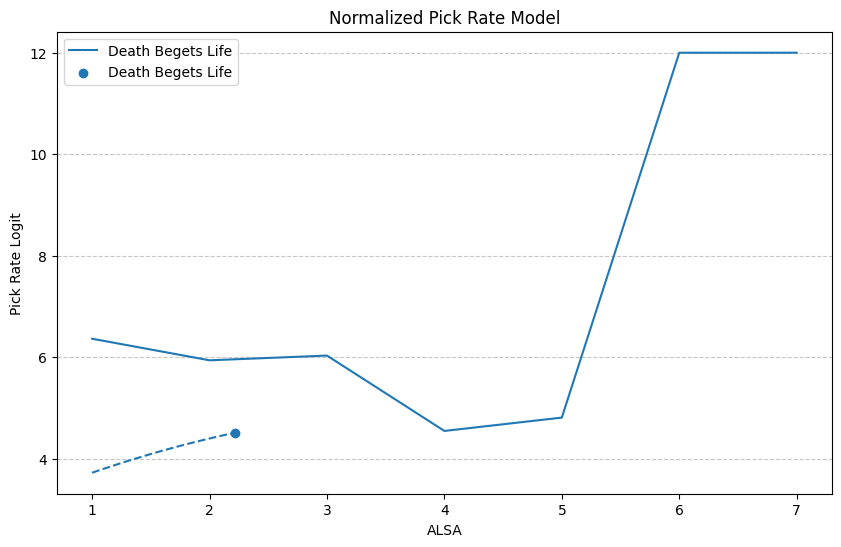

In [29]:
ax = line_plot(card_df.sort('pick_num').pivot(on="name", index="pick_num", values="pick_rate_logit"), return_ax=True)
# _, ax = plt.subplots(figsize=(24,16))
for row in card_means.to_dicts():
    ax.scatter(row['alsa'], row['pick_rate_logit'], label=row['name'])
    (x, y) = npr_curve(row['alsa'], row['pick_rate_logit'])
    ax.plot(x, y, linestyle='--')
ax.set_title('Normalized Pick Rate Model')    
ax.set_ylabel('Pick Rate Logit')
ax.set_xlabel('ALSA')
ax.legend()

pick_num,seen_pick_odds_log_sum,num_taken
i8,f64,i32
1,17.54695,12329
2,16.727273,12329
3,16.421192,12329
4,16.17463,12329
5,15.906989,12329
…,…,…
10,14.201328,12329
11,13.729598,12329
12,13.167841,12329
